In [22]:
!pwd

/home/dinh/graph-based_action-recognition


In [3]:
%cd ../..

/home/dinh/graph-based_action-recognition


In [ ]:
%matplotlib widget

"""
Illustrate skeletons from a .skeleton file of the "NTU RGB+D 3D Action Recognition Dataset"

Argument:
    filename: full adress and filename of the .skeleton file.
"""

import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from ipywidgets import Button, IntSlider, HBox, VBox
from IPython.display import display
from Src.Tools.read_skeleton_file import read_skeleton_file


"""
In the skeleton structure, each joint is connected to some other joints. To faciliate the illustration, we suppose that each joint has 
only one neighbor.

For further information, please refer to:
    NTU RGB+D dataset's webpage:
       http://rose1.ntu.edu.sg/Datasets/actionRecognition.asp
    NTU RGB+D dataset's github page:
       https://github.com/shahroudy/NTURGB-D
""" 
CONNECTING_JOINT = [2, 1, 21, 3, 21, 5, 6, 7, 21, 9, 10, 11,
                    1, 13, 14, 15, 1, 17, 18, 19, 2, 8, 8, 12, 12]

def draw_frame(ax, bodies, zoom_factor):
    ax.clear()
    ax.axis('off')
    width = 1920 / zoom_factor
    height = 1080 / zoom_factor
    ax.set_xlim((1920 - width) / 2, (1920 + width) / 2)
    ax.set_ylim((1080 + height) / 2, (1080 - height) / 2)
    for body in bodies:
        joints = body.joints
        for j in range(25):
            k = CONNECTING_JOINT[j] - 1
            if 0 <= k < 25:
                x1, y1 = joints[j].colorX, joints[j].colorY
                x2, y2 = joints[k].colorX, joints[k].colorY
                ax.plot([x1, x2], [y1, y2], color='blue', linewidth=2)
        for joint in joints:
            ax.scatter(joint.colorX, joint.colorY, c='red', s=20)

def display_widget(filename):
    # --- Load skeleton data ---
    skeleton_data = read_skeleton_file(filename)
    total_frames = len(skeleton_data)

    # --- Global state ---
    state = {
        "current_frame": 1,
        "zoom_factor": 1.0,
        "is_playing": True,
        "slider_is_moving": False
    }

    fig, ax = plt.subplots(figsize=(8, 4.5))

    # --- Update frame ---
    def update(frame):
        state["current_frame"] = frame
        draw_frame(ax, skeleton_data[frame - 1], state["zoom_factor"])
        ax.set_title(f"Frame: {frame} / {total_frames}")
        if not state["slider_is_moving"]:
            frame_slider.value = frame

    anim = FuncAnimation(fig, update, frames=range(1, total_frames + 1), interval=100)
    anim.event_source.stop()

    # --- Button callbacks ---
    def on_play_pause_clicked(b):
        if state["is_playing"]:
            anim.event_source.stop()
            b.description = "Play"
        else:
            anim.event_source.start()
            b.description = "Pause"
        state["is_playing"] = not state["is_playing"]

    def on_step_clicked(b):
        if state["current_frame"] < total_frames:
            state["current_frame"] += 1
            anim.event_source.stop()
            play_pause_btn.description = "Play"
            update(state["current_frame"])
            state["is_playing"] = False

    def on_replay_clicked(b):
        # Reset state
        state["current_frame"] = 1
        state["zoom_factor"] = 1.0
        state["is_playing"] = True
        anim.event_source.stop()
        play_pause_btn.description = "Play"
        update(1)

    def on_zoom_in_clicked(b):
        state["zoom_factor"] *= 1.25
        update(state["current_frame"])

    def on_zoom_out_clicked(b):
        state["zoom_factor"] /= 1.25
        update(state["current_frame"])

    def on_save_gif_clicked(b):
        gif_name = os.path.splitext(os.path.basename(filename))[0] + ".gif"
        print(f"Saving animation to {gif_name}...")
        temp_anim = FuncAnimation(fig, update, frames=range(1, total_frames + 1), interval=100, repeat=False)
        temp_anim.save(gif_name, writer=PillowWriter(fps=10))
        print("GIF saved successfully.")

    def on_close_clicked(b):
        anim.event_source.stop()
        plt.close(fig)

    def on_frame_slider_change(change):
        if change['name'] == 'value':
            state["slider_is_moving"] = True
            new_frame = change['new']
            if new_frame != state["current_frame"]:
                state["current_frame"] = new_frame
                anim.event_source.stop()
                play_pause_btn.description = "Play"
                state["is_playing"] = False
                update(new_frame)
            state["slider_is_moving"] = False

    # --- Widgets ---
    play_pause_btn = Button(description="Pause")
    play_pause_btn.on_click(on_play_pause_clicked)

    step_btn = Button(description="Step")
    step_btn.on_click(on_step_clicked)

    replay_btn = Button(description="Replay")
    replay_btn.on_click(on_replay_clicked)

    zoom_in_btn = Button(description="Zoom In")
    zoom_in_btn.on_click(on_zoom_in_clicked)

    zoom_out_btn = Button(description="Zoom Out")
    zoom_out_btn.on_click(on_zoom_out_clicked)

    save_gif_btn = Button(description="Save GIF")
    save_gif_btn.on_click(on_save_gif_clicked)

    close_btn = Button(description="Close")
    close_btn.on_click(on_close_clicked)

    frame_slider = IntSlider(value=1, min=1, max=total_frames, description='Frame')
    frame_slider.observe(on_frame_slider_change, names='value')

    controls = HBox([
        play_pause_btn, step_btn, replay_btn,
        zoom_in_btn, zoom_out_btn, save_gif_btn,
        close_btn
    ])

    ui = VBox([controls, frame_slider])
    display(ui)

def draw_skeleton(filename: str, save: bool = False):
    if save:
        print("Saving directly to GIF...")
        skeleton_data = read_skeleton_file(filename)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        def update(frame):
            draw_frame(ax, skeleton_data[frame - 1], zoom_factor=1.0)
            ax.set_title(f"Frame: {frame} / {len(skeleton_data)}")
        anim = FuncAnimation(fig, update, frames=range(1, len(skeleton_data) + 1), interval=100, repeat=False)
        gif_name = os.path.splitext(os.path.basename(filename))[0] + ".gif"
        anim.save(gif_name, writer=PillowWriter(fps=10))
        print(f"GIF saved to: {gif_name}")
    else:
        display_widget(filename)


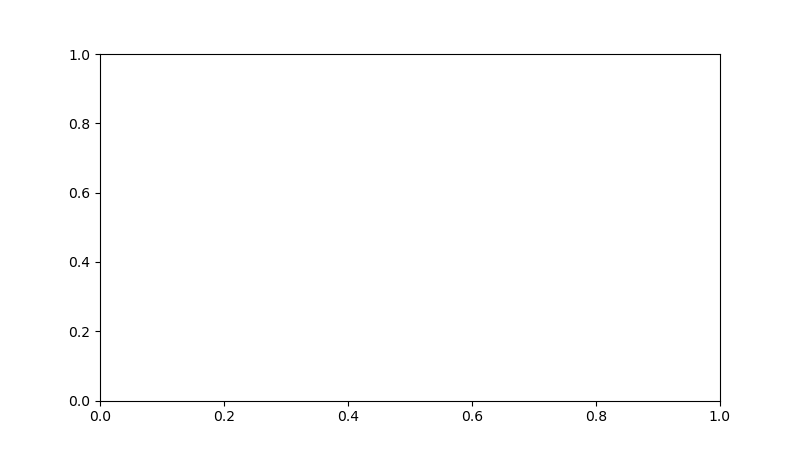

In [28]:
draw_skeleton('Dataset/nturgb+d_skeletons/S001C001P001R001A002.skeleton', save=False)

In [ ]:
draw_skeleton('Dataset/nturgb+d_skeletons/S001C001P001R001A001.skeleton', save=False)